Notebook

In [15]:
import pandas as pd
df = pd.read_csv("data/salesdaily.csv")

print(df.shape)
print(df.dtypes)
print(df.head())
print(df.isnull().sum())

(2106, 13)
datum            object
M01AB           float64
M01AE           float64
N02BA           float64
N02BE           float64
N05B            float64
N05C            float64
R03             float64
R06             float64
Year              int64
Month             int64
Hour              int64
Weekday Name     object
dtype: object
      datum  M01AB  M01AE  N02BA  N02BE  N05B  N05C   R03  R06  Year  Month  \
0  1/2/2014    0.0   3.67    3.4  32.40   7.0   0.0   0.0  2.0  2014      1   
1  1/3/2014    8.0   4.00    4.4  50.60  16.0   0.0  20.0  4.0  2014      1   
2  1/4/2014    2.0   1.00    6.5  61.85  10.0   0.0   9.0  1.0  2014      1   
3  1/5/2014    4.0   3.00    7.0  41.10   8.0   0.0   3.0  0.0  2014      1   
4  1/6/2014    5.0   1.00    4.5  21.70  16.0   2.0   6.0  2.0  2014      1   

   Hour Weekday Name  
0   248     Thursday  
1   276       Friday  
2   276     Saturday  
3   276       Sunday  
4   276       Monday  
datum           0
M01AB           0
M01AE         

In [16]:
import pandas as pd

df = pd.read_csv("data/salesdaily.csv")

# Ubah kolom tanggal dari string → datetime

df["datum"] = pd.to_datetime(df["datum"])

# Ekstrak kolom turunan yang nanti berguna
df["year"]  = df["datum"].dt.year
df["month"] = df["datum"].dt.month

print(df.head())


       datum  M01AB  M01AE  N02BA  N02BE  N05B  N05C   R03  R06  Year  Month  \
0 2014-01-02    0.0   3.67    3.4  32.40   7.0   0.0   0.0  2.0  2014      1   
1 2014-01-03    8.0   4.00    4.4  50.60  16.0   0.0  20.0  4.0  2014      1   
2 2014-01-04    2.0   1.00    6.5  61.85  10.0   0.0   9.0  1.0  2014      1   
3 2014-01-05    4.0   3.00    7.0  41.10   8.0   0.0   3.0  0.0  2014      1   
4 2014-01-06    5.0   1.00    4.5  21.70  16.0   2.0   6.0  2.0  2014      1   

   Hour Weekday Name  year  month  
0   248     Thursday  2014      1  
1   276       Friday  2014      1  
2   276     Saturday  2014      1  
3   276       Sunday  2014      1  
4   276       Monday  2014      1  


In [17]:
import pandas as pd

df = pd.read_csv("data/salesdaily.csv")

# Kolom obat = semua kecuali datum, year, month
kolom_obat = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]

total_per_kategori = df[kolom_obat].sum()
print(total_per_kategori)

M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
N02BE    63005.402708
N05B     18645.737500
N05C      1249.958333
R03      11608.822917
R06       6107.817500
dtype: float64


In [18]:
total_per_kategori = df[kolom_obat].sum()

# Urutkan dari terbesar
total_urut = total_per_kategori.sort_values(ascending=False)
print(total_urut)

N02BE    63005.402708
N05B     18645.737500
R03      11608.822917
M01AB    10600.937083
M01AE     8204.618646
N02BA     8172.209000
R06       6107.817500
N05C      1249.958333
dtype: float64


In [21]:
# Januari 2015
jan_2015 = df[(df["Year"] == 2015) & (df["Month"] == 1)]
total_jan2015 = jan_2015[kolom_obat].sum().sort_values(ascending=False)
print("Top 3 Januari 2015:")
print(total_jan2015.head(3))

# Juli 2016
jul_2016 = df[(df["Year"] == 2016) & (df["Month"] == 7)]
total_jul2016 = jul_2016[kolom_obat].sum().sort_values(ascending=False)
print("\nTop 3 Juli 2016:")
print(total_jul2016.head(3))

# September 2017 — coba kerjakan sendiri dengan pola yang sama!
sep_2017 = df[(df["Year"] == 2017) & (df["Month"] == 9)]
total_sep2017 = sep_2017[kolom_obat].sum().sort_values(ascending=False)
print("\nTop 3 September 2017:")
print(total_sep2017.head(3))

Top 3 Januari 2015:
N02BE    1044.24
N05B      463.00
R03       177.25
dtype: float64

Top 3 Juli 2016:
N02BE    652.362000
N05B     240.000000
M01AB    194.528333
dtype: float64

Top 3 September 2017:
N02BE    863.75
N05B     223.00
R03      139.00
dtype: float64


In [23]:
tahun_2017 = df[df["Year"] == 2017]
total_2017 = tahun_2017[kolom_obat].sum().sort_values(ascending=False)
print("Obat terlaris 2017:", total_2017.idxmax())
print(total_2017)

Obat terlaris 2017: N02BE
N02BE    9258.804833
N05B     2555.541667
R03      1893.614583
M01AB    1846.617083
M01AE    1387.298333
N02BA    1288.295833
R06       988.860000
N05C      180.333333
dtype: float64


In [24]:
rata2_harian = df[kolom_obat].mean()
print(rata2_harian.sort_values(ascending=False))

N02BE    29.917095
N05B      8.853627
R03       5.512262
M01AB     5.033683
M01AE     3.895830
N02BA     3.880441
R06       2.900198
N05C      0.593522
dtype: float64


In [26]:
r03_per_bulan = df.groupby("Month")["R03"].mean()
print(r03_per_bulan)

Month
1     6.835980
2     6.896943
3     6.290323
4     5.771528
5     5.006944
6     4.350000
7     2.956989
8     3.102151
9     4.402315
10    7.208589
11    6.226667
12    7.916129
Name: R03, dtype: float64


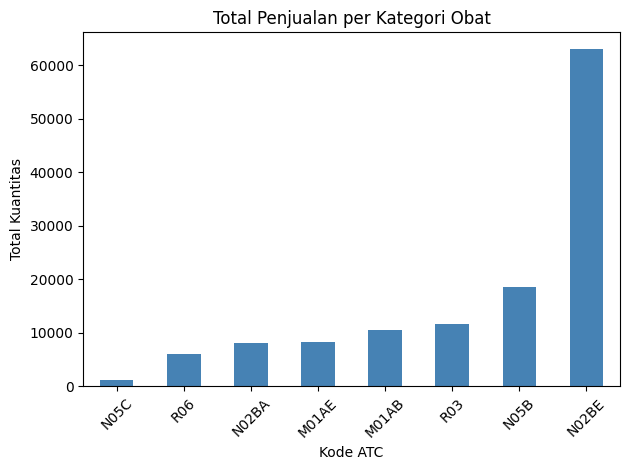

In [29]:
import matplotlib.pyplot as plt

total_per_kategori.sort_values().plot(kind="bar", color="steelblue")

plt.title("Total Penjualan per Kategori Obat")
plt.xlabel("Kode ATC")
plt.ylabel("Total Kuantitas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

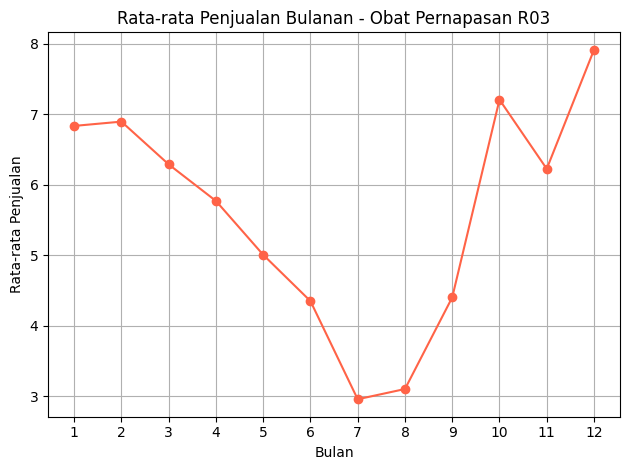

In [30]:
r03_per_bulan.plot(kind="line", marker="o", color="tomato")

plt.title("Rata-rata Penjualan Bulanan - Obat Pernapasan R03")
plt.xlabel("Bulan")
plt.ylabel("Rata-rata Penjualan")
plt.xticks(range(1, 13))   # label 1 sampai 12
plt.grid(True)
plt.tight_layout()
plt.show()